# TP Diffusion - Sommerfeld - Analyse des images

## Partie 1 - Extraction de $h$ en fonction du temps

# TP Diffusion - Sommerfeld - Analyse des images

## Partie 1 - Extraction de $h$ en fonction du temps

L’objectif de cette partie est de déterminer la déflexion verticale maximale $h$ du faisceau laser en fonction du temps à partir des images expérimentales. Cette grandeur permet ensuite d’étudier l’évolution temporelle de l’angle de déviation maximal $\alpha_{\max}$ du faisceau. Cet angle n’est pas mesuré directement : il est déduit de la valeur de $h$, correspondant à la distance verticale entre la trajectoire déviée du faisceau et sa trajectoire rectiligne de référence.

Dans cette première partie, après un prétraitement des images sous Fiji (seuillage et squelettisation), les coordonnées des pixels constituant la feuille laser sont exportées. Le traitement est ensuite réalisé sous Python : à partir des coordonnées $(x,y)$, la trajectoire du faisceau est reconstruite pour chaque image, une droite de référence est déterminée, puis la déflexion verticale maximale est calculée. 
 

On renseigne le nom du dossier ainsi que le facteur de conversion pixel/m (imageJ).


In [1]:
import numpy as np

csv_path = "skeleton_pixels.csv"   # adapte le nom si besoin
csv_data = np.loadtxt(csv_path, delimiter=",", skiprows=1)

# ex:(3331.66 px = 15 cm, PX_TO_M = 0.15 / 3331.66)
PX_TO_M = 0.15 / 3331.66


### 1. Extraction de la trajectoire du faisceau et calcul de la déviation

À partir du fichier \texttt{CSV} contenant les coordonnées $(x,y)$ des pixels du squelette pour chaque image, un traitement est effectué sous Python afin de reconstruire la trajectoire de la feuille laser et d’en extraire la déflexion verticale maximale. Pour chaque image, la position verticale du faisceau est estimée colonne par colonne comme la médiane des coordonnées $y$ associées à une même abscisse $x$, ce qui permet d’obtenir une courbe robuste vis-à-vis des petites irrégularités du squelette. La courbe est ensuite interpolée et lissée à l’aide d’un filtre gaussien afin d’obtenir une trajectoire continue. Une droite de référence, correspondant à la trajectoire rectiligne du faisceau à l’équilibre diffusif, est déterminée à partir de la première image et conservée pour l’ensemble de la séquence. La déflexion verticale est alors définie comme la différence entre la trajectoire reconstruite et la droite de référence. La hauteur maximale $h$ est identifiée comme la valeur maximale positive de cette déflexion dans une région d’intérêt.


In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter1d



# Reconstruit la courbe y(x) à partir des points (x,y) en prenant, pour chaque x, la médiane des y associés

def curve_from_xy(xs, ys, W):
    # Tableau contenant y(x) pour x = 0 ... W-1
    y = np.full(W, np.nan)

    # Pour chaque colonne x présente dans les données
    for x in np.unique(xs):
        # On prend la médiane des valeurs y correspondantes
        y[x] = np.median(ys[xs == x])

    return y



# Calcule la déflexion verticale maximale h pour chaque image à partir d'un fichier CSV contenant slice, x, y

def dmax_from_csv(csv_data, ref=None,
                  roi_left=0.1, roi_right=0.9,
                  edge_margin=0.05, smooth_sigma=10.0):

    # Séparation des colonnes du CSV
    slices = csv_data[:, 0].astype(int)   # numéro d'image
    xs_all = csv_data[:, 1].astype(int)   # coordonnées x
    ys_all = csv_data[:, 2].astype(float) # coordonnées y

    results = []   # contiendra (slice, dmax)

    # Boucle sur toutes les images du stack
    for s in np.unique(slices):

        # Sélection des points correspondant à l'image s
        sel = slices == s
        xs = xs_all[sel]
        ys = ys_all[sel]

        # Largeur de l'image (en pixels)
        W = xs.max() + 1

        # Reconstruction de la courbe brute y(x)
        y_raw = curve_from_xy(xs, ys, W)

        # Colonnes pour lesquelles on a une valeur valide
        valid = np.isfinite(y_raw)
        x_valid = np.where(valid)[0]

        # Si trop peu de points valides, on renvoie h = 0
        if x_valid.size < 5:
            results.append((s, 0.0))
            continue

        # Interpolation pour obtenir une courbe continue
        y_interp = np.interp(np.arange(W),
                              x_valid,
                              y_raw[valid])

        # Lissage par filtre gaussien
        y_smooth = gaussian_filter1d(y_interp,
                                     sigma=smooth_sigma)

        # Construction de la droite de référence (uniquement sur la première image)
        if ref is None:

            # On ignore les bords de l'image
            m = int(edge_margin * W)
            good = np.isfinite(y_smooth)
            good[:m] = False
            good[W - m:] = False

            xs_ref = np.where(good)[0]

            x1, x2 = xs_ref[0], xs_ref[-1]
            y1, y2 = y_smooth[x1], y_smooth[x2]

            # Stockage de la référence
            ref = (x1, y1, x2, y2)

        else:
            x1, y1, x2, y2 = ref

        # Équation de la droite de référence
        slope = (y2 - y1) / (x2 - x1)
        xgrid = np.arange(W)
        y_line = y1 + slope * (xgrid - x1)

        # Calcul de la déflexion verticale
        d = y_smooth - y_line

        # Définition de la région d'intérêt
        xmin = int(roi_left * W)
        xmax = int(roi_right * W)

        good = np.isfinite(d) & (d > 0)
        good[:xmin] = False
        good[xmax:] = False

        # Hauteur maximale
        dmax = float(np.max(d[good])) if np.any(good) else 0.0

        results.append((s, dmax))

    return np.array(results), ref



### 5. Traitement de l’ensemble de la séquence d’images

On applique maintenant la fonction précédente à toutes les images du dossier.
Pour chaque image, la déviation verticale maximale est calculée en pixels,
puis convertie en mètres.


In [3]:
results, ref = dmax_from_csv(csv_data)

PX_TO_M = 0.15 / 3331.66   # m / pixel

# Conversion pixels -> mètres
h = results.copy()
h[:,1] *= PX_TO_M
h = h[:, 1]

print("h (m)")
print(h)



h (m)
[0.03362712 0.0289725  0.02590277 0.02375002 0.02167061 0.02065062
 0.01907387 0.01813387 0.01740366 0.01672681 0.01594266 0.01551507
 0.01488414 0.01423902 0.01405938 0.01361022 0.01333295 0.01288098
 0.01261227 0.01219133 0.01191853 0.01168561 0.01160764 0.01144467
 0.01115715 0.0109435  0.01085528 0.0106354  0.01045537]


### 5. Visualisation

La fonction show permet de visualiser, pour une image donnée, le résultat final de la détection
du creux de la feuille laser.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def compute_curve_and_d(csv_data, slice_id, ref,
                        roi_left=0.1, roi_right=0.9,
                        smooth_sigma=10.0):

    slices = csv_data[:,0].astype(int)
    xs_all = csv_data[:,1].astype(int)
    ys_all = csv_data[:,2].astype(float)

    sel = slices == slice_id
    xs = xs_all[sel]
    ys = ys_all[sel]

    W = xs.max() + 1
    xgrid = np.arange(W)

    # reconstruction courbe
    y_raw = curve_from_xy(xs, ys, W)

    valid = np.isfinite(y_raw)
    x_valid = np.where(valid)[0]

    y_interp = np.interp(xgrid, x_valid, y_raw[valid])
    y_smooth = gaussian_filter1d(y_interp, sigma=smooth_sigma)

    # ligne de référence
    x1, y1, x2, y2 = ref
    slope = (y2 - y1)/(x2 - x1)
    y_line = y1 + slope*(xgrid - x1)

    # déflexion
    d = y_smooth - y_line

    xmin = int(roi_left * W)
    xmax = int(roi_right * W)

    good = np.isfinite(d) & (d > 0)
    good[:xmin] = False
    good[xmax:] = False

    if not np.any(good):
        return xgrid, y_smooth, y_line, d, None, 0.0

    idx = np.argmax(np.where(good, d, -np.inf))
    dmax = float(d[idx])

    return xgrid, y_smooth, y_line, d, idx, dmax

def plot_slice(csv_data, slice_id, ref,
                     roi_left=0.1, roi_right=0.9,
                     smooth_sigma=10.0,
                     px_to_m=None):
    xgrid, y_smooth, y_line, d, idx, dmax = compute_curve_and_d(
        csv_data, slice_id, ref,
        roi_left=roi_left, roi_right=roi_right,
        smooth_sigma=smooth_sigma
    )

    # conversions optionnelles (pour afficher h en mètres)
    dmax_disp = dmax
    unit = "px"
    if px_to_m is not None:
        dmax_disp = dmax * px_to_m
        unit = "m"

    plt.figure()
    plt.plot(xgrid, y_smooth, label="Courbe (médiane + lissage)")
    plt.plot(xgrid, y_line, label="Ligne de référence")

    if idx is not None:
        # segment vertical montrant h
        plt.plot([idx, idx], [y_line[idx], y_smooth[idx]], linewidth=2)
        plt.scatter([idx], [y_smooth[idx]])
        plt.scatter([idx], [y_line[idx]])
        plt.title(f"Slice {slice_id} — h = {dmax_disp:.4g} {unit} (idx={idx})")
    else:
        plt.title(f"Slice {slice_id} — aucune déflexion positive dans la ROI")

    plt.xlabel("x (pixels)")
    plt.ylabel("y (pixels)")
    plt.legend()
    plt.gca().invert_yaxis()  # optionnel: comme une image (y vers le bas)
    plt.show()


En faisant varier l’indice i, il est possible d’accéder à chaque image individuellement et d’identifier la position du creux détecté par l’algorithme. 

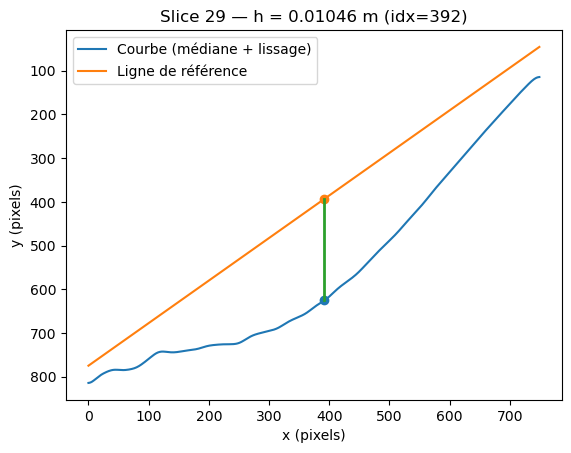

In [9]:
plot_slice(csv_data, slice_id=29, ref=ref,
                 roi_left=0.1, roi_right=0.9,
                 smooth_sigma=10.0,
                 px_to_m=PX_TO_M)

# Partie 2 – Détermination du coefficient de diffusion $D$

À l’issue de la partie 1, on dispose d’une liste \texttt{h} contenant, pour chaque instant, la déflexion verticale maximale $h$ de la feuille laser.

L’angle de déviation maximal du faisceau, noté $\alpha_{\max}$, n’est pas mesuré directement. Il est déduit de la géométrie expérimentale à partir de la relation

$$
\alpha_{\max} = \arctan\left(\frac{h}{X}\right),
$$

où $X$ désigne la distance entre la sortie de la cuve et l’écran.

D’après le modèle théorique de l’expérience de Sommerfeld, cet angle vérifie

$$
\alpha_{\max}(t)
= d\,\frac{n_g - n_w}{c_g}\,\frac{c_0}{2\sqrt{\pi D t}},
$$

ce qui montre que, à temps suffisamment long, on attend un comportement diffusif de la forme

$$
\alpha_{\max}(t)\propto t^{-1/2}.
$$

Un tracé en échelle log-log est particulièrement adapté pour tester cette loi de puissance : si le régime est bien diffusif, les points doivent s’aligner approximativement sur une droite de pente voisine de $-1/2$.

---

## Travail demandé

1. À partir des valeurs de $h(t)$ obtenues à la partie 1, calculer l’angle de déviation maximal $\alpha_{\max}(t)$.

2. Tracer $\alpha_{\max}$ en fonction du temps en échelle log-log.

3. Vérifier si le comportement observé est compatible avec le régime diffusif attendu, c’est-à-dire avec une loi en $t^{-1/2}$. On commentera notamment la pente obtenue sur le graphe log-log.

4. Ajuster les données expérimentales à l’aide de l’équation théorique reliant $\alpha_{\max}$ au temps afin d’en déduire le coefficient de diffusion $D$. On se placera dans le domaine des temps longs (par exemple $t \gtrsim 1$ h), pour lequel le régime asymptotique diffusif est atteint et la loi $\alpha_{\max}(t)\propto t^{-1/2}$ est vérifiée. Sur cette portion des données, effectuer un ajustement permettant d’extraire la pente correspondante. Cette pente est ensuite reliée au coefficient de diffusion $D$ à partir de l’expression théorique donnée précédemment. En déduire la valeur expérimentale de $D$.

5. Propager les incertitudes expérimentales afin d’estimer l’incertitude sur $D$.

6. En déduire, en supposant valable la relation de Stokes--Einstein pour les molécules de glycérol, un ordre de grandeur de la taille typique d’une molécule de glycérol. 

On rappelle que la relation de Stokes--Einstein relie le coefficient de diffusion $D$ d’une particule de rayon $R$ à la température $T$ et à la viscosité dynamique $\eta$ du solvant :

$$
D = \frac{k_B T}{6 \pi \eta R},
$$

où $k_B$ est la constante de Boltzmann. 

On prendra :
$
k_B = 1.38 \times 10^{-23}\ \text{J·K}^{-1}
$

et, pour l’eau à température ambiante,

$
\eta \simeq 1.0 \times 10^{-3}\ \text{Pa·s}.
$